In [39]:
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "DeepUnitMatch"))
sys.path = list(set(sys.path))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import mat73
import sqlite3
from DeepUnitMatch.utils.helpers import PROJECT_ROOT


RESULTS_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results_no_conflict_filter"

Plot Similarity matrices

In [ ]:
def create_sim_mat(df, col):
    sessions = df["RecSes1"].iloc[1] == df["RecSes2"].iloc[1]
    if sessions:
        l1 = l2 = int(np.sqrt(len(df)))
    else:
        l1 = len(df["ID1"].unique())
        l2 = len(df["ID2"].unique())
        assert l1 * l2 == len(df)
    if col == "index":
        vals = np.array(df.index).astype(int)
    else:
        vals = np.array(df[col])
    vals = vals.reshape((l1, l2))
    return vals


def create_concat_mat(
    df11, df12, df21, df22, col, sort_method="id", rec1=None, rec2=None, depths=None
):
    s11 = create_sim_mat(df11, col)
    s12 = create_sim_mat(df12, col)
    s21 = create_sim_mat(df21, col)
    s22 = create_sim_mat(df22, col)

    if sort_method == "depth":
        s11 = reorder_by_depth(s11, depths, rec1, rec1)
        s12 = reorder_by_depth(s12, depths, rec1, rec2)
        s21 = reorder_by_depth(s21, depths, rec2, rec1)
        s22 = reorder_by_depth(s22, depths, rec2, rec2)

    top_row = np.concatenate((s11, s12), axis=1)
    bottom_row = np.concatenate((s21, s22), axis=1)

    sim_matrix = np.concatenate((top_row, bottom_row))
    return sim_matrix

def compare_two_recordings(
    df: pd.DataFrame, rec1: int, rec2: int, sort_method="id", depths=None, vis=False
):
    """
    df: matchtable as a pandas DataFrame
    rec1: integer corresponding to the RecSes1 that you want to select
    rec2: integer corresponding to the RecSes2 that you want to select
    sort_method: how you want the results to be sorted (depth or id)
    depths: only required if sort_method="depth". can read depths directly from matlab using the
    read_depths function.
    """
    # Pick out the relevant columns and ensure they are sorted
    col = df.loc[:, "WavformSim":"LocTrajectorySim"]
    df["NoLocScore"] = col.mean(axis=1)
    df = df.loc[
        :, ["RecSes1", "RecSes2", "ID1", "ID2", "DNNSim", "MatchProb", "NoLocScore"]
    ]
    df11 = df.loc[(df["RecSes1"] == rec1) & (df["RecSes2"] == rec1), :]
    df12 = df.loc[(df["RecSes1"] == rec1) & (df["RecSes2"] == rec2), :]
    df21 = df.loc[(df["RecSes1"] == rec2) & (df["RecSes2"] == rec1), :]
    df22 = df.loc[(df["RecSes1"] == rec2) & (df["RecSes2"] == rec2), :]

    if sort_method == "depth":
        sim_matrix = create_concat_mat(
            df11, df12, df21, df22, "DNNSim", "depth", rec1, rec2, depths
        )
        indices = create_concat_mat(
            df11, df12, df21, df22, "index", "depth", rec1, rec2, depths
        )
        um_output = create_concat_mat(
            df11, df12, df21, df22, "MatchProb", "depth", rec1, rec2, depths
        )
        um_score = create_concat_mat(
            df11, df12, df21, df22, "NoLocScore", "depth", rec1, rec2, depths
        )
    elif sort_method == "id":
        sim_matrix = create_concat_mat(df11, df12, df21, df22, "DNNSim", "id")
        um_output = create_concat_mat(df11, df12, df21, df22, "MatchProb")
        um_score = create_concat_mat(df11, df12, df21, df22, "NoLocScore")
    else:
        raise ValueError("""Please pick a sorting method from 'depth' or 'id'
                         Default is id as this requires no info about spatial positions of neurons.
                         Depth gives better results though.""")
    if vis:
        fig, (ax1, ax2, ax3) = plt.subplots(ncols=3)
        ax1.matshow(sim_matrix)
        ax1.set_title("DNN Similarity matrix")

        ax2.matshow(um_output)
        ax2.set_title("UnitMatch match probabilities")

        ax3.matshow(um_score)
        ax3.set_title("UnitMatch score (no centroid)")

        plt.show()
    return sim_matrix, indices


def get_cross_day_matrices(df: pd.DataFrame, rec1: int, rec2: int, depths=None):

    df11 = df.loc[(df["RecSes1"] == rec1) & (df["RecSes2"] == rec1), :]
    df12 = df.loc[(df["RecSes1"] == rec1) & (df["RecSes2"] == rec2), :]
    df21 = df.loc[(df["RecSes1"] == rec2) & (df["RecSes2"] == rec1), :]
    df22 = df.loc[(df["RecSes1"] == rec2) & (df["RecSes2"] == rec2), :]
    s12 = reorder_by_depth(create_sim_mat(df12, "DNNSim"), depths, rec1, rec2)
    s21 = reorder_by_depth(create_sim_mat(df21, "DNNSim"), depths, rec2, rec1)
    indices = create_concat_mat(
        df11, df12, df21, df22, "index", "depth", rec1, rec2, depths
    )

    return s12, s21, indices


def reorder_by_depth(matrix: np.ndarray, depths, recses1: int, recses2: int):
    """
    Reorders a square block matrix by depth within each session's block.

    This function assumes the matrix has a shape of (n1+n2) x (n1+n2), where
    the first n1 rows/columns correspond to neurons from `recses1` and the
    following n2 rows/columns correspond to neurons from `recses2`.

    The reordering sorts the first n1 rows/cols by the depth of recses1 neurons,
    and sorts the next n2 rows/cols by the depth of recses2 neurons,
    preserving the overall block structure.

    Args:
        matrix (np.ndarray): The square comparison matrix, shape (n1+n2, n1+n2).
        depths (pd.DataFrame): DataFrame with "RecSes" and "depth" columns.
        recses1 (int): The ID for the first recording session (first block).
        recses2 (int): The ID for the second recording session (second block).

    Returns:
        np.ndarray: The reordered matrix.
    """
    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError("Input matrix must be square.")

    # 1. Filter depths for each session and get their counts.
    depths1 = depths[depths["RecSes"] == recses1].copy()
    depths2 = depths[depths["RecSes"] == recses2].copy()
    n1, n2 = len(depths1), len(depths2)

    # 2. Validate that the total number of neurons matches the matrix dimension.
    if n1 + n2 != matrix.shape[0]:
        raise ValueError(
            f"The total number of neurons from recses {recses1} ({n1}) and {recses2} ({n2}) "
            f"does not match the matrix dimension ({matrix.shape[0]})."
        )

    # 3. Get the sorting indices for the first session's neurons.
    # These indices will range from 0 to n1-1, which is what we want for the first block.
    sort_indices_s1 = np.argsort(depths1["depth"].values)

    # 4. Get the sorting indices for the second session's neurons.
    # These indices also range from 0 to n2-1 initially.
    sort_indices_s2_raw = np.argsort(depths2["depth"].values)
    # We must offset them to correctly target the second block of the matrix (indices n1 to n1+n2-1).
    sort_indices_s2_offset = sort_indices_s2_raw + n1

    # 5. Concatenate the indices to create a single permutation vector for the entire matrix.
    # This vector first reorders the 0..n1-1 block, then the n1..n1+n2-1 block.
    full_sort_indices = np.concatenate([sort_indices_s1, sort_indices_s2_offset])

    # 6. Apply this single permutation vector to both the rows and columns.
    # Using np.ix_ is the canonical way to reorder rows and columns independently.
    # This correctly reorders each block while preserving its position.
    reordered_matrix = matrix[np.ix_(full_sort_indices, full_sort_indices)]

    return reordered_matrix


In [42]:
mouse = 'AL036'
probe = '19011116882'
loc = '3'
conn = sqlite3.connect(os.path.join(PROJECT_ROOT, "matchtables_algo.db"))
df = pd.read_sql_query(f"SELECT * FROM {mouse}_{probe}_{loc}", conn)

depths = read_depths(mouse, probe, loc)

sim_matrix, idx = compare_two_recordings(df, 19, 20, "depth", depths, vis=True)

KeyError: 'WavformSim'

In [45]:
df.keys()

Index(['ID1', 'ID2', 'RecSes1', 'RecSes2', 'Matches_DeepUnitMatch',
       'UM Probabilities_DeepUnitMatch', 'TotalScore_DeepUnitMatch',
       'distance_DeepUnitMatch', 'ISI_correlations', 'ISI_KL_divergence',
       'ISI_wasserstein_distance', 'refpop_correlations_DeepUnitMatch',
       'FR_diff', 'ISI_CV_diff', 'UID orig 1', 'UID orig 2',
       'UID Lib 1_DeepUnitMatch', 'UID Lib 2_DeepUnitMatch',
       'UID 1_DeepUnitMatch', 'UID 2_DeepUnitMatch',
       'UID Cons 1_DeepUnitMatch', 'UID Cons 2_DeepUnitMatch',
       'natim_correlations_DeepUnitMatch', 'Matches_UMPy',
       'UM Probabilities_UMPy', 'TotalScore_UMPy', 'amp_score_UMPy',
       'spatial_decay_score_UMPy', 'centroid_overlord_score_UMPy',
       'centroid_dist_UMPy', 'waveform_score_UMPy', 'trajectory_score_UMPy',
       'refpop_correlations_UMPy', 'UID Lib 1_UMPy', 'UID Lib 2_UMPy',
       'UID 1_UMPy', 'UID 2_UMPy', 'UID Cons 1_UMPy', 'UID Cons 2_UMPy',
       'natim_correlations_UMPy', 'Matches_EMD', 'UM Probabilit

In [ ]:
### tests on read_depths

base = r"\\znas\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData"
# Find Unitmatch.mat for each recording

data = np.load(os.path.join(base, mouse, probe, loc, "DeepUnitMatch", "WaveformInfo.npz"))
print(np.shape(data['avg_centroid']))

um_path = os.path.join(base, mouse, probe, loc, "UnitMatch", "UnitMatch.mat")
um = mat73.loadmat(um_path, verbose=False)
pl = um["WaveformInfo"]["ProjectedLocation"]  # shape [3 x Nclus x 2]
x = pl[1, :, :]  # shape [Nclus x 2]
y = pl[2, :, :]
x = np.array(np.round(np.mean(x, axis=1), decimals=-2))
y = np.array(np.mean(y, axis=1))
if len(np.unique(x)) != 4:
    print(f"CAUTION: Found {len(np.unique(x))} clusters of x values rather than 4.")
uid = um["UniqueIDConversion"]["OriginalClusID"]
urs = um["UniqueIDConversion"]["recsesAll"]
goodids = um["UniqueIDConversion"]["GoodID"]
uid, urs = uid[goodids == 1], urs[goodids == 1]
depth = x * 1e6 + y
depth_dict = {"RecSes": urs, "ID": uid, "IDrank": "", "depth": depth}
depth_df = pd.DataFrame(depth_dict)


import pickle
param = pickle.load(open(r"\\znas\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\AL032\19011111882\1\DeepUnitMatch\UMparam.pickle", 'rb'))
np.shape(param['good_units'][1])

(3, 41, 2)


(19, 1)

Plot UMAP

In [1]:

import os
import sys

sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.dirname(os.getcwd()))
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "DeepUnitMatch"))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
import umap.umap_ as umap
from tqdm import tqdm
import h5py
import pickle

c:\Users\celia\anaconda3\envs\UMPy\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
import numpy as np
import pandas as pd
import os
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader
from testing.test import load_trained_model
from utils.helpers import get_unit_id
from utils.npdataset import NeuropixelsDataset_cortexlab, ValidationExperimentBatchSampler


def embed_data(
    data_dir,
    ks_dirs=None,
    unit_order: str = "filesystem",
    load_bombcell: bool = False,
):
    """
    Embed every unit in `data_dir` using the trained DeepUnitMatch model.

    Required data structures
    -------------------------
    data_dir : a directory whose immediate children are per-session subfolders
        (named by session index, e.g. "0", "1", ...), each containing
        `Unit{id}_RawSpikes.npy` HDF5 files with `waveform` ([T, C, 2]) and
        `MaxSitepos` ([2]) datasets. This is exactly the `processed_waveforms`
        folder produced by `param_fun.get_snippets(...)` in the main
        `DeepUnitMatch.ipynb` demo notebook, and the same directory passed to
        `testing.test.inference`.

    ks_dirs : only required when `load_bombcell=True`. A list of raw
        KiloSort/UnitMatch output directory paths, one per session, in the
        *same order* the sessions were originally passed to `get_snippets`
        (i.e. the same list as `KS_dirs` in the main demo notebook,
        index-aligned with the session folders in `data_dir`). Each entry is
        expected to have a `qMetrics/templates._bc_qMetrics.parquet` file
        (Bombcell's output, historically fetched from the cortexlab server
        share) -- see `get_bombcell_data` for the expected column schema.

    Returns
    -------
    A dict with one row per unit:
        "embedded_first" / "embedded_second": (N, 256) DNN embeddings for
            each cross-validation half.
        "session_id": int session index (position of that unit's session
            folder in `sorted(os.listdir(data_dir))`).
        "unit_id": the unit's cluster ID within its session.
        "depth": the unit's depth (MaxSitepos[:, 1]).
        "bombcell": (only when `load_bombcell=True`) dict of Bombcell QC
            columns -> list of values, aligned with the other arrays.
    """
    if load_bombcell and not ks_dirs:
        raise ValueError("ks_dirs is required when load_bombcell=True")

    model = load_trained_model()
    test_dataset = NeuropixelsDataset_cortexlab(data_dir, unit_order=unit_order)
    test_sampler = ValidationExperimentBatchSampler(test_dataset, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_sampler=test_sampler)

    embedded_first, embedded_second = [], []
    session_ids, unit_ids_all, depths = [], [], []
    bc_values = {} if load_bombcell else None

    with torch.no_grad():
        for waveforms_fh, waveforms_sh, msp, exp_ids_i, filepaths_i in tqdm(test_loader):
            bsz_i = waveforms_fh.shape[0]
            session_id = int(exp_ids_i[0])  # same for every file in the batch
            unit_ids = [get_unit_id(f) for f in filepaths_i]

            enc_fh = model(waveforms_fh).numpy()  # shape [bsz, 256]
            enc_sh = model(waveforms_sh).numpy()  # shape [bsz, 256]
            embedded_first.extend(enc_fh)
            embedded_second.extend(enc_sh)
            session_ids.extend([session_id] * bsz_i)
            unit_ids_all.extend(unit_ids)
            depths.extend(msp[:, 1].tolist())

            if load_bombcell:
                n_before = len(bc_values.get("clusterID", []))
                bc_values, _ = get_bombcell_data(
                    bc_values, ks_dirs[session_id], unit_ids=unit_ids
                )
                n_added = len(bc_values["clusterID"]) - n_before
                if n_added != bsz_i:
                    raise ValueError(
                        f"Session {session_id}: expected {bsz_i} Bombcell rows for "
                        f"this batch's units, found {n_added}. Check that ks_dirs is "
                        f"index-aligned with the session folders in data_dir."
                    )

    result = {
        "embedded_first": np.array(embedded_first),
        "embedded_second": np.array(embedded_second),
        "session_id": np.array(session_ids),
        "unit_id": np.array(unit_ids_all),
        "depth": np.array(depths),
    }
    if load_bombcell:
        result["bombcell"] = bc_values
    return result


def get_bombcell_data(existing, exp_server_path, unit_ids=None):
    """
    Load Bombcell data for one session.

    Called once per session by `embed_data` (one session == one batch, since
    `ValidationExperimentBatchSampler` batches by experiment).

    Args:
        - existing: dictionary of bombcell parameters -> list of values for each neuron.
        - exp_server_path: this session's raw KiloSort/UnitMatch output directory (an
          entry of `ks_dirs`), expected to contain
          `qMetrics/templates._bc_qMetrics.parquet` with (at least) the columns listed
          below.
        - unit_ids: the IDs to get data for (only want good IDs, and post-merge)
    """
    parquet_path = os.path.join(
        exp_server_path, "qMetrics", "templates._bc_qMetrics.parquet"
    )

    if not os.path.exists(parquet_path): 
            parquet_path = os.path.join(
            exp_server_path, "templates._bc_qMetrics.parquet"
        )
        
    columns = [
        "clusterID",
        "percentageSpikesMissing_gaussian",
        "presenceRatio",
        "nSpikes",
        "nPeaks",
        "nTroughs",
        "isSomatic",
        "waveformDuration_peakTrough",
        "spatialDecaySlope",
        "waveformBaselineFlatness",
        "rawAmplitude",
    ]
    bc = pd.read_parquet(parquet_path)
    bc["clusterID"] = (bc["clusterID"] - 1).astype(int)

    if unit_ids is not None:
        bc = bc.loc[bc["clusterID"].isin(unit_ids)]

    if len(existing.keys()) == 0:
        for col in columns:
            existing[col] = bc[col].values.tolist()
    else:
        for col in columns:
            if col not in bc.columns:
                existing[col].extend([np.nan] * len(bc))
            else:
                existing[col].extend(bc[col].values.tolist())

    return existing, False

In [ ]:
# Forward pass the data through the network
#
# Each entry below is one "location" (e.g. one mouse/probe/loc): `data_dir`
# is a `processed_waveforms` folder as produced by `param_fun.get_snippets(...)`
# in the main DeepUnitMatch.ipynb demo (session-index-named subfolders of
# Unit{id}_RawSpikes.npy HDF5 files). `ks_dirs` is only needed if
# `load_bombcell=True`: it's the same `KS_dirs` list used to build that
# location's `processed_waveforms` folder, index-aligned with its session
# subfolders, so Bombcell's `qMetrics/templates._bc_qMetrics.parquet` can be
# found per session.

# from utils.helpers import PROJECT_ROOT
PROJECT_ROOT = r"\\znas\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026V2" # will plot non-merged data
DATABASE_PATH = r"\\znas\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\matchtables_algo.db" # just to load the valid locations

from utils.helpers import get_locations_from_sqlite

# Get all valid locations first to avoid repeated file system checks
valid_locations = get_locations_from_sqlite(
    db_path=DATABASE_PATH
)

load_bombcell = True
locations = []
for mouse, probe, loc in valid_locations:
    data_dir = os.path.join(PROJECT_ROOT, mouse, probe, loc, "DeepUnitMatch", "tmp_waveforms","processed_waveforms")
    param = pickle.load(open( os.path.join(PROJECT_ROOT, mouse, probe, loc, "DeepUnitMatch", "UMparam.pickle"), 'rb'))

    ks_dirs = param['KS_dirs'] if load_bombcell else None

    locations.append(
        {
            "name": mouse,
            "data_dir": data_dir,
            "ks_dirs": ks_dirs,  # e.g. the KS_dirs list used to build data_dir above, if load_bombcell=True
        },
    )

umap_path = PROJECT_ROOT + r"\UMAP"

embedded_1_parts, embedded_2_parts = [], []
session_id_parts, unit_id_parts, depth_parts, location_parts = [], [], [], []
bombcell_parts = [] if load_bombcell else None

for loc_idx, loc in enumerate(locations):
    result = embed_data(
        loc["data_dir"], ks_dirs=loc.get("ks_dirs"), load_bombcell=load_bombcell
    )
    embedded_1_parts.append(result["embedded_first"])
    embedded_2_parts.append(result["embedded_second"])
    session_id_parts.append(result["session_id"])
    unit_id_parts.append(result["unit_id"])
    depth_parts.append(result["depth"])
    location_parts.append(np.full(len(result["depth"]), loc_idx))
    if load_bombcell:
        bombcell_parts.append(result["bombcell"])

embedded_1 = np.concatenate(embedded_1_parts)
embedded_2 = np.concatenate(embedded_2_parts)
session_id = np.concatenate(session_id_parts)
unit_id = np.concatenate(unit_id_parts)
depths = np.concatenate(depth_parts)
location = np.concatenate(location_parts)
location_names = [loc["name"] for loc in locations]

if load_bombcell:
    bc = {
        col: sum((part[col] for part in bombcell_parts), [])
        for col in bombcell_parts[0]
    }
    pd.DataFrame(bc).to_csv(os.path.join(umap_path, "bombcell.csv"))

np.save(os.path.join(umap_path, "first_half.npy"), embedded_1)
np.save(os.path.join(umap_path, "second_half.npy"), embedded_2)
np.save(os.path.join(umap_path, "depths.npy"), depths)
np.save(os.path.join(umap_path, "location.npy"), location)

In [40]:
# Compute and save UMAP embeddings

n_neighbours = 5
min_dist = 0.1
n_components = 2
metric = "euclidean"

umap_embedding = umap.UMAP(n_neighbours, n_components, metric, min_dist=min_dist, random_state=0).fit_transform(0.5 * (embedded_1 + embedded_2), axis=0)
np.save(os.path.join(umap_path, "UMAPembeddings.npy"), umap_embedding)

c:\Users\celia\anaconda3\envs\UMPy\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\celia\AppData\Local\Temp\ipykernel_9944\1006678657.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_labels))
C:\Users\celia\AppData\Local\Temp\ipykernel_9944\1006678657.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


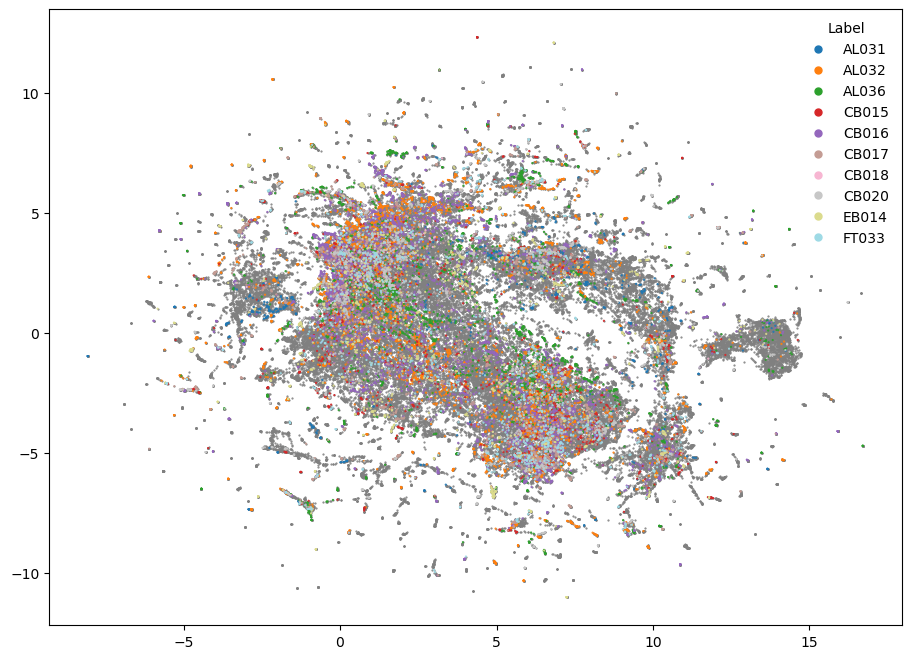

In [83]:
# Plot the UMAP embeddings
chosen_locations = ['CB015', 'CB016', 'CB017', 'CB018', 'CB020', 'FT033', 'EB014', 'AL031', 'AL032', 'AL036']
# chosen_locations = ['AV009', 'AV015', 'AV021']
# chosen_locations = ['JF084']

umap_embedding = np.load(os.path.join(umap_path, "UMAPembeddings.npy"))

fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=False)

if chosen_locations is not None:
    mask = np.array([location_names[idx] in chosen_locations for idx in location])
    label_names = [location_names[idx] for idx in location if location_names[idx] in chosen_locations]
    umap_to_plot = umap_embedding[mask]
    umap_background = umap_embedding
else:
    label_names = [location_names[idx] for idx in location]
    umap_to_plot = umap_embedding
    umap_background = None

# Map each unique label name to one color so duplicate labels share the same color.
unique_labels = list(dict.fromkeys(label_names))
label_to_code = {label: i for i, label in enumerate(unique_labels)}
color_codes = [label_to_code[label] for label in label_names]

cmap = plt.cm.get_cmap("tab20", len(unique_labels))

if umap_background is not None:
    scatter = ax.scatter(
        x=umap_background[:, 0],
        y=umap_background[:, 1],
        s=0.3,
        c='grey',
        cmap=cmap,
    )

scatter = ax.scatter(
    x=umap_to_plot[:, 0],
    y=umap_to_plot[:, 1],
    s=0.3,
    c=color_codes,
    cmap=cmap,
)

handles = [
    plt.Line2D(
        [],
        [],
        marker="o",
        linestyle="",
        markersize=5,
        color=cmap(i),
    )
    for i in range(len(unique_labels))
]

ax.legend(handles, unique_labels, title="Label", loc="best", frameon=False)
plt.show()

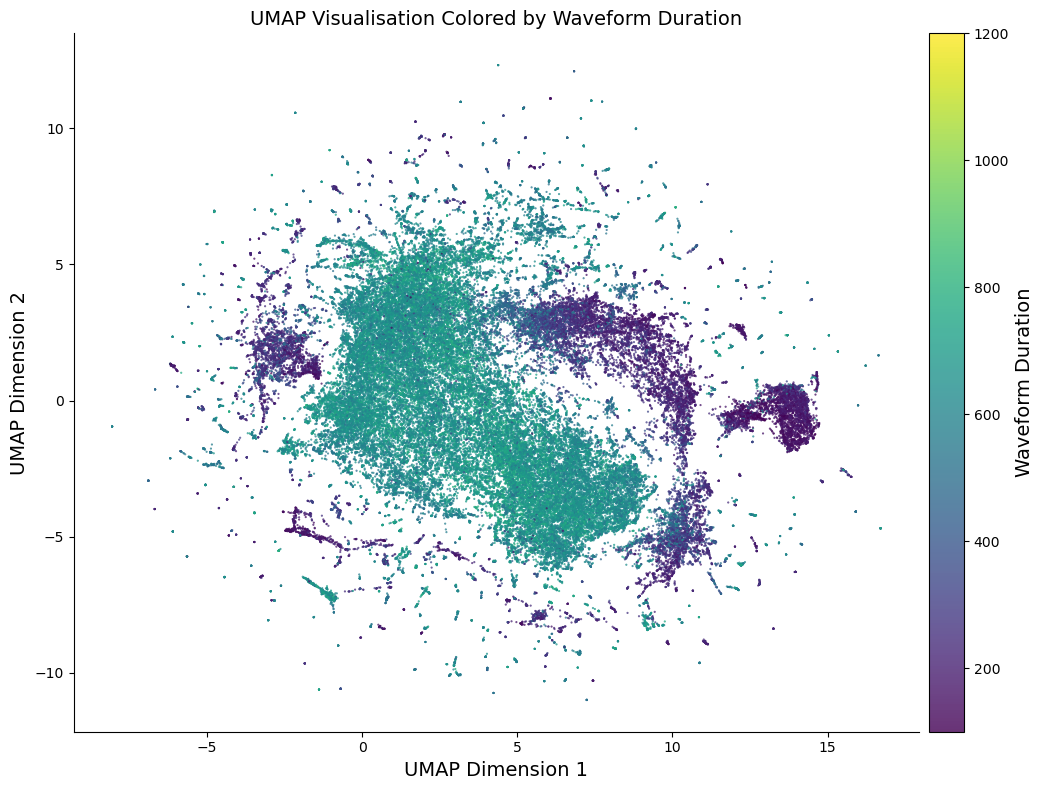

In [84]:
# Colour code UMAP by Bombcell output
# Requires load_bombcell = True (and ks_dirs supplied per location) in the
# "Forward pass" cell above, so that `bc` was populated there.
bc_param = "waveformDuration_peakTrough"
# bc_param = "spatialDecaySlope"
# bc_param = "rawAmplitude"
# bc_param = "waveformBaselineFlatness"

umap_to_plot = umap_embedding

if bc_param == "rawAmplitude":
    df = pd.DataFrame(bc)
    df = df.loc[df["rawAmplitude"] < 500]
    mask = np.zeros(len(bc[bc_param]), dtype=bool)
    for i in df.index:
        mask[i] = True
    umap_to_plot = umap_embedding[mask]
    colours = df[bc_param].values
elif bc_param == "nSpikes":
    df = pd.DataFrame(bc)
    df = df.loc[df["nSpikes"] < 50000]
    mask = np.zeros(len(bc[bc_param]), dtype=bool)
    for i in df.index:
        mask[i] = True
    umap_to_plot = umap_embedding[mask]
    colours = df[bc_param].values
elif bc_param == "spatialDecaySlope":
    df = pd.DataFrame(bc)
    df = df.loc[df["spatialDecaySlope"] < 0]
    df = df.loc[df["spatialDecaySlope"] > -0.015]
    mask = np.zeros(len(bc[bc_param]), dtype=bool)
    for i in df.index:
        mask[i] = True
    umap_to_plot = umap_embedding[mask]
    colours = df[bc_param].values
else:
    umap_to_plot = umap_embedding
    colours = bc[bc_param]

fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=False)
cmap = plt.cm.viridis
scatter = ax.scatter(
    x=umap_to_plot[:, 0],
    y=umap_to_plot[:, 1],
    s=0.3,  # Small point size
    c=colours,
    cmap=cmap,
    alpha=0.8,
)
cbar = plt.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label("Waveform Duration", fontsize=14)
ax.set_title("UMAP Visualisation Colored by Waveform Duration", fontsize=14)
ax.set_xlabel("UMAP Dimension 1", fontsize=14)
ax.set_ylabel("UMAP Dimension 2", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.rcParams["svg.fonttype"] = "none"
ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)
plt.show()